In [1]:
import numpy as np
import matplotlib.pyplot as plt

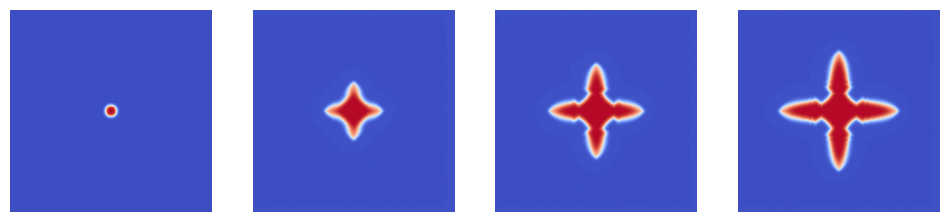

In [2]:
solutions = np.load("./data/train_valid/solutions_grid.npy")[3, :, 0, ...]
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 60, 120, 160]

fig, axes = plt.subplots(1, len(tics), figsize=(12, 3))
axes = axes.flatten()
for i, tic in enumerate(tics):
    ax = axes[i]
    ax.contourf(meshx, meshy, solutions[tic, :, :], levels=100, cmap='coolwarm')
    ax.set_aspect('equal')
    ax.set_axis_off()

In [3]:
from configs.train_debug import Configs
configs = Configs()
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
times = np.load("./data/train_valid/times.npy")
dt = times[1] - times[0]
num_times = times.shape[0]
solutions = np.load("./data/train_valid/solutions_grid.npy")
num_ks = solutions.shape[0]
Xs = np.zeros(
    (num_ks * (num_times - 1), 5, 
     mesh.shape[1], mesh.shape[2])
) # 4: phi, T, meshx, meshy, k
Ys = np.zeros(
    (num_ks * (num_times - 1), 2, 
     mesh.shape[1], mesh.shape[2])
) # 2: phi, T
K_values = np.load("./data/train_valid/K_values.npy")
Ks = np.zeros((num_ks * (num_times - 1), 1))

for i in range(num_ks):
    Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
    Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # T
    Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = meshx / configs.Lc  # meshx
    Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = meshy / configs.Lc  # meshy
    Xs[i*(num_times-1):(i+1)*(num_times-1), 4, :, :] = K_values[i]  # k

    Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi
    Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # T

    Ks[i*(num_times-1):(i+1)*(num_times-1), 0] = K_values[i]

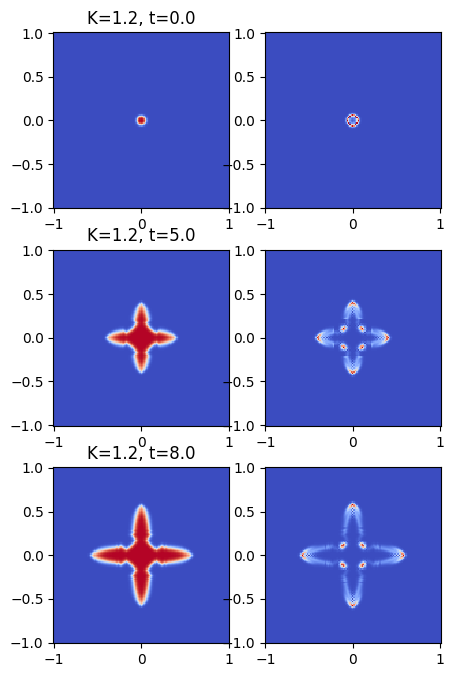

In [8]:
import matplotlib.pyplot as plt
ts = [0, 100, 159]
fig, axes = plt.subplots(3, 2, figsize=(5, 8))
for idx, t in enumerate(ts):
    t += 160*3
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 2, :, :] * configs.Lc
    meshy = Xs[t, 3, :, :] * configs.Lc
    ax = axes[idx, 0]
    im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.set_aspect('equal')
    k = Ks[t, 0]
    ax.set_title(f"K={k:.1f}, t={ts[idx] * dt:.1f}")

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.set_aspect('equal')


In [9]:
# solutions[0, 100, 1, :, :].min(), solutions[0, 100, 1, :, :].max()
np.max(solutions[0, :, 1, :, :], axis=(1,2))

array([ 4.99600361e-17, -1.09406560e-02, -3.08154990e-02, -5.18189575e-02,
       -7.03882283e-02, -8.60099134e-02, -9.89069501e-02, -1.09382605e-01,
       -1.17780615e-01, -1.24443646e-01, -1.29687256e-01, -1.33781607e-01,
       -1.36950513e-01, -1.39374944e-01, -1.37439626e-01, -1.33854124e-01,
       -1.30343009e-01, -1.25484851e-01, -1.23255054e-01, -1.18917962e-01,
       -1.15646380e-01, -1.13868944e-01, -1.08744668e-01, -1.06462113e-01,
       -1.04206232e-01, -1.00356174e-01, -9.86030223e-02, -9.54447432e-02,
       -9.24785990e-02, -9.11136588e-02, -8.82674889e-02, -8.57582385e-02,
       -8.46214017e-02, -8.14878798e-02, -7.93167442e-02, -7.83366662e-02,
       -7.57735862e-02, -7.37590255e-02, -7.28495539e-02, -7.02927273e-02,
       -6.83718581e-02, -6.74764559e-02, -6.56518844e-02, -6.37130610e-02,
       -6.27724027e-02, -6.11999444e-02, -5.91837419e-02, -5.81347710e-02,
       -5.74848108e-02, -5.52980485e-02, -5.40843330e-02, -5.39298039e-02,
       -5.15598305e-02, -

In [10]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Ks=Ks,
    Xs=Xs,
    Ys=Ys,
)

In [11]:
print(mesh[0])
print(mesh[1])

[[-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 ...
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]]
[[-1.       -1.       -1.       ... -1.       -1.       -1.      ]
 [-0.984375 -0.984375 -0.984375 ... -0.984375 -0.984375 -0.984375]
 [-0.96875  -0.96875  -0.96875  ... -0.96875  -0.96875  -0.96875 ]
 ...
 [ 0.96875   0.96875   0.96875  ...  0.96875   0.96875   0.96875 ]
 [ 0.984375  0.984375  0.984375 ...  0.984375  0.984375  0.984375]
 [ 1.        1.        1.       ...  1.        1.        1.      ]]
